Checking dataset structure...
Validation folder not found, will split from training data
Found 6 classes: ['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']
Creating test set from training data split

Dataset sizes:
Training: 4399 samples
Validation: 1467 samples
Test: 1470 samples
Total: 7336 samples

Training class distribution:
Chickenpox: 436 (9.9%)
Cowpox: 369 (8.4%)
HFMD: 966 (22.0%)
Healthy: 697 (15.8%)
Measles: 302 (6.9%)
Monkeypox: 1629 (37.0%)

Validation class distribution:
Chickenpox: 146 (10.0%)
Cowpox: 123 (8.4%)
HFMD: 322 (21.9%)
Healthy: 232 (15.8%)
Measles: 101 (6.9%)
Monkeypox: 543 (37.0%)

Test class distribution:
Chickenpox: 146 (9.9%)
Cowpox: 124 (8.4%)
HFMD: 322 (21.9%)
Healthy: 233 (15.9%)
Measles: 101 (6.9%)
Monkeypox: 544 (37.0%)


/tmp/ipykernel_35/1852262765.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_35/1852262765.py:277: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


Epoch 01:
Train Loss: 1.0728 | Acc: 0.6990 | AUC: 0.9407
Val Loss: 0.9131 | Acc: 0.9196 | AUC: 0.9937
Epoch 02:
Train Loss: 0.8667 | Acc: 0.8159 | AUC: 0.9745
Val Loss: 0.8991 | Acc: 0.9202 | AUC: 0.9958
Epoch 03:
Train Loss: 0.8035 | Acc: 0.8595 | AUC: 0.9818
Val Loss: 0.8227 | Acc: 0.9686 | AUC: 0.9982
Epoch 04:
Train Loss: 0.7714 | Acc: 0.8772 | AUC: 0.9865
Val Loss: 0.7858 | Acc: 0.9789 | AUC: 0.9985
Epoch 05:
Train Loss: 0.7393 | Acc: 0.8941 | AUC: 0.9901
Val Loss: 0.8146 | Acc: 0.9632 | AUC: 0.9977
Epoch 06:
Train Loss: 0.7191 | Acc: 0.9070 | AUC: 0.9914
Val Loss: 0.8005 | Acc: 0.9646 | AUC: 0.9986
Epoch 07:
Train Loss: 0.7244 | Acc: 0.9025 | AUC: 0.9897
Val Loss: 0.8287 | Acc: 0.9584 | AUC: 0.9994
Epoch 08:
Train Loss: 0.7123 | Acc: 0.9102 | AUC: 0.9918
Val Loss: 0.8185 | Acc: 0.9550 | AUC: 0.9995
Epoch 09:
Train Loss: 0.6885 | Acc: 0.9250 | AUC: 0.9935
Val Loss: 0.7389 | Acc: 0.9973 | AUC: 0.9999
Epoch 10:
Train Loss: 0.6723 | Acc: 0.9295 | AUC: 0.9950
Val Loss: 0.7492 | Acc: 0

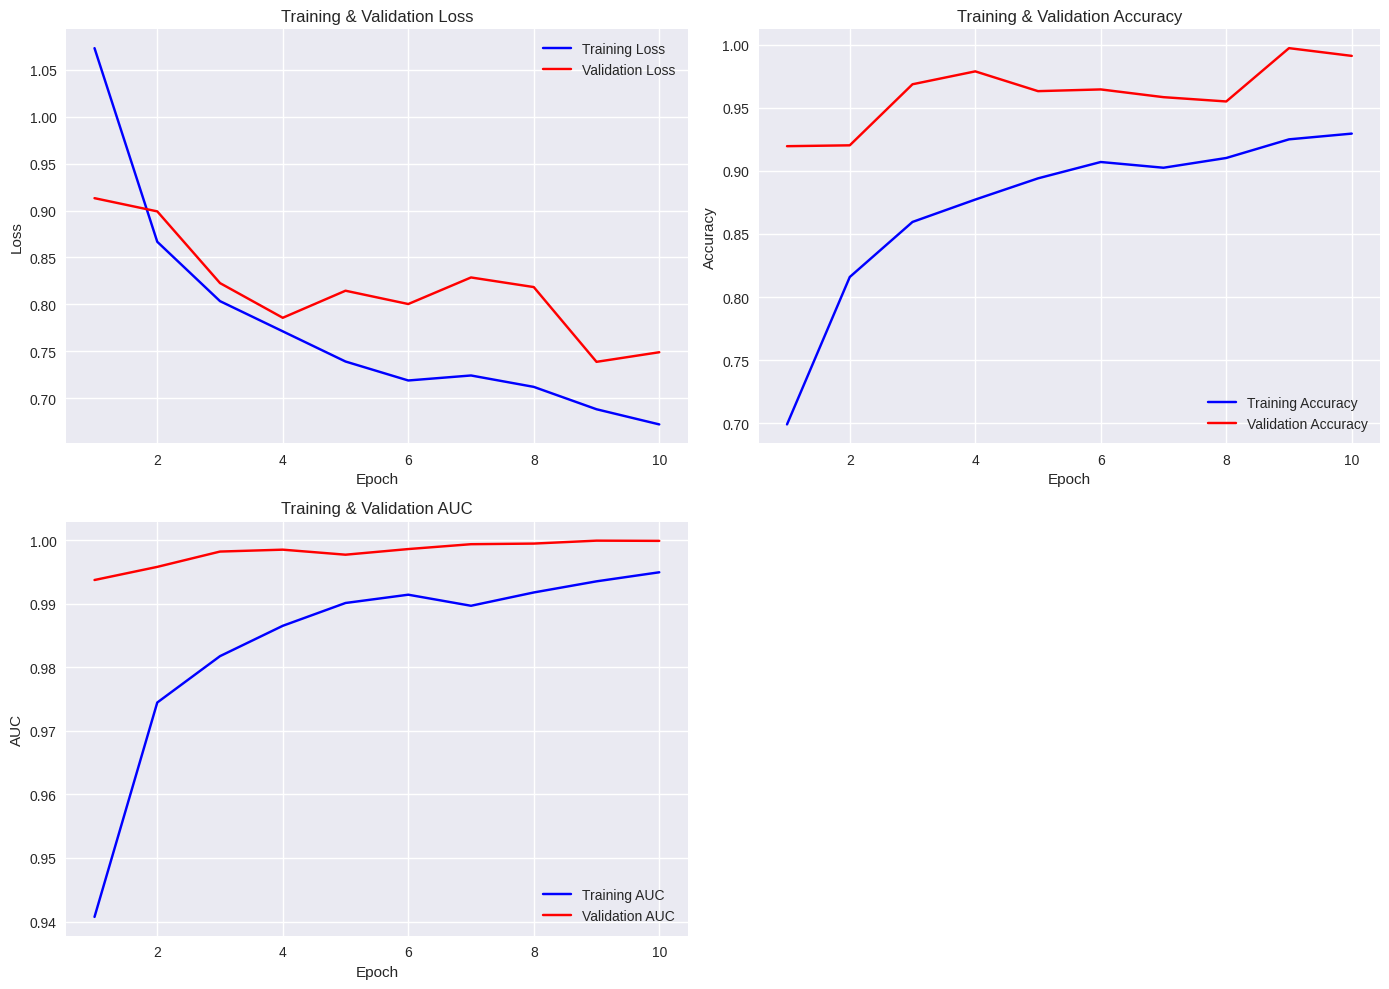


Test Accuracy: 0.9925 | Test AUC: 0.9998


In [ ]:
# ======================
# 1. Setup & Imports
# ======================
!pip install -q timm torchmetrics wandb

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import timm
from timm.data import create_transform
from timm.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
import torchmetrics
from torch.cuda.amp import GradScaler, autocast

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configuration
IMG_SIZE = 224  # Standard size for Swin Transformer
BATCH_SIZE = 32  # Adjust based on your GPU memory

# ======================
# 2. Robust Dataset Preparation
# ======================
dataset_path = "/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Augmented Images/Augmented Images/FOLDS_AUG/fold4_AUG"
train_path = os.path.join(dataset_path, "Train")

# Verify paths exist
print("Checking dataset structure...")
if not os.path.exists(train_path):
    raise FileNotFoundError(f"Train folder not found at {train_path}")

# Handle Test folder
test_path = os.path.join(dataset_path, "Test")
if not os.path.exists(test_path):
    print("Warning: Test folder not found, will use 20% of training as test set")
    test_path = None

# Handle Val folder
val_path = os.path.join(dataset_path, "Val")
if not os.path.exists(val_path):
    print("Validation folder not found, will split from training data")
    val_path = None

# Get class names from train folder
CLASS_NAMES = sorted(os.listdir(train_path))
NUM_CLASSES = len(CLASS_NAMES)
print(f"Found {NUM_CLASSES} classes: {CLASS_NAMES}")

# ======================
# 3. Dataset Class with Automatic Splitting
# ======================
class SkinLesionDataset(Dataset):
    def __init__(self, root_dir, transform=None, mode='train', test_size=0.2, seed=42):
        """
        Args:
            root_dir: Root directory containing class folders
            transform: Optional transform to be applied
            mode: One of 'train', 'val', or 'test'
            test_size: Fraction of data to use for validation/test
            seed: Random seed for reproducibility
        """
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.samples = []
        
        np.random.seed(seed)
        
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
                
            files = [f for f in sorted(os.listdir(class_dir)) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            np.random.shuffle(files)
            
            # Split into train/val/test
            if mode == 'train':
                files = files[:int(len(files) * (1 - 2*test_size))]
            elif mode == 'val':
                files = files[int(len(files) * (1 - 2*test_size)):int(len(files) * (1 - test_size))]
            elif mode == 'test':
                files = files[int(len(files) * (1 - test_size)):]
            
            for fname in files:
                path = os.path.join(class_dir, fname)
                self.samples.append((path, self.class_to_idx[class_name]))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, target = self.samples[idx]
        
        try:
            image = plt.imread(path)
            if len(image.shape) == 2:  # Grayscale
                image = np.stack([image]*3, axis=-1)
            elif image.shape[2] == 4:  # RGBA
                image = image[:, :, :3]
                
            image = transforms.ToPILImage()(image)
            
            if self.transform:
                image = self.transform(image)
                
            return image, target
        except Exception as e:
            print(f"Error loading {path}: {str(e)}")
            # Return a random image if there's an error
            dummy_img = torch.rand(3, IMG_SIZE, IMG_SIZE)
            return dummy_img, 0

# ======================
# 4. Create Datasets and Dataloaders
# ======================
# Create transforms
train_transform = create_transform(
    input_size=IMG_SIZE,
    is_training=True,
    color_jitter=0.4,
    auto_augment='rand-m9-mstd0.5-inc1',
    interpolation='bicubic',
    re_prob=0.25,
    re_mode='pixel',
    re_count=1,
)

val_transform = create_transform(
    input_size=IMG_SIZE,
    is_training=False,
    interpolation='bicubic',
)

# Create datasets
train_dataset = SkinLesionDataset(train_path, transform=train_transform, mode='train')
val_dataset = SkinLesionDataset(train_path, transform=val_transform, mode='val')

if test_path:
    test_dataset = SkinLesionDataset(test_path, transform=val_transform, mode='test')
else:
    print("Creating test set from training data split")
    test_dataset = SkinLesionDataset(train_path, transform=val_transform, mode='test')

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# Print dataset sizes
print(f"\nDataset sizes:")
print(f"Training: {len(train_dataset)} samples")
print(f"Validation: {len(val_dataset)} samples")
print(f"Test: {len(test_dataset)} samples")
print(f"Total: {len(train_dataset)+len(val_dataset)+len(test_dataset)} samples")

# Verify class distribution
def print_class_distribution(dataset, name):
    counts = {cls: 0 for cls in dataset.classes}
    for _, label in dataset.samples:
        counts[dataset.classes[label]] += 1
    print(f"\n{name} class distribution:")
    for cls, count in counts.items():
        print(f"{cls}: {count} ({count/len(dataset):.1%})")

print_class_distribution(train_dataset, "Training")
print_class_distribution(val_dataset, "Validation")
print_class_distribution(test_dataset, "Test")

# ======================
# 5. Swin Transformer Model
# ======================
class SwinTransformerModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        self.model = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=pretrained,
            num_classes=0,  # Remove classifier
        )
        self.num_features = self.model.num_features
        self.fc = nn.Linear(self.num_features, num_classes)
        
        # Freeze initial layers
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze last 2 stages
        for block in self.model.layers[-2:]:
            for param in block.parameters():
                param.requires_grad = True
                
    def forward(self, x):
        features = self.model(x)
        return self.fc(features)

model = SwinTransformerModel()
model = model.to('cuda')

# ======================
# 6. Advanced Training Setup
# ======================
# Class weights
targets = [target for _, target in train_dataset.samples]
class_weights = compute_class_weight('balanced', classes=np.unique(targets), y=targets)
class_weights = torch.FloatTensor(class_weights).to('cuda')

# Loss function with label smoothing
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Optimizer with weight decay
optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05,
    eps=1e-8
)

# Mixed precision training
scaler = GradScaler()

# Learning rate scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

# Metrics
train_metrics = {
    'acc': torchmetrics.Accuracy(task='multiclass', num_classes=NUM_CLASSES).to('cuda'),
    'auc': torchmetrics.AUROC(task='multiclass', num_classes=NUM_CLASSES).to('cuda')
}

val_metrics = {
    'acc': torchmetrics.Accuracy(task='multiclass', num_classes=NUM_CLASSES).to('cuda'),
    'auc': torchmetrics.AUROC(task='multiclass', num_classes=NUM_CLASSES).to('cuda')
}

# ======================
# 7. Training Loop with History Tracking
# ======================
# Initialize history dictionary
history = {
    'train_loss': [],
    'train_acc': [],
    'train_auc': [],
    'val_loss': [],
    'val_acc': [],
    'val_auc': []
}

best_val_acc = 0.0
patience = 5
current_patience = 0

def train_epoch(model, loader, optimizer, criterion, scaler, metrics):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to('cuda'), labels.to('cuda')
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        metrics['acc'](outputs.softmax(dim=1), labels)
        metrics['auc'](outputs.softmax(dim=1), labels)
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = metrics['acc'].compute().item()
    epoch_auc = metrics['auc'].compute().item()
    
    metrics['acc'].reset()
    metrics['auc'].reset()
    
    return epoch_loss, epoch_acc, epoch_auc

def validate_epoch(model, loader, criterion, metrics):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to('cuda'), labels.to('cuda')
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            all_preds.append(outputs.softmax(dim=1))
            all_labels.append(labels)
            
            metrics['acc'](outputs.softmax(dim=1), labels)
            metrics['auc'](outputs.softmax(dim=1), labels)
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = metrics['acc'].compute().item()
    epoch_auc = metrics['auc'].compute().item()
    
    metrics['acc'].reset()
    metrics['auc'].reset()
    
    return epoch_loss, epoch_acc, epoch_auc

# Training loop
for epoch in range(10):
    train_loss, train_acc, train_auc = train_epoch(
        model, train_loader, optimizer, criterion, scaler, train_metrics
    )
    
    val_loss, val_acc, val_auc = validate_epoch(
        model, val_loader, criterion, val_metrics
    )
    
    # Store metrics in history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    
    scheduler.step()
    
    print(f"Epoch {epoch+1:02d}:")
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | AUC: {train_auc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | AUC: {val_auc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_swin.pth')
        current_patience = 0
    else:
        current_patience += 1
        if current_patience >= patience:
            print("Early stopping triggered")
            break

# ======================
# 8. Plot Training History
# ======================
# ======================
# 8. Plot Training History (Fixed Version)
# ======================
def plot_training_history(history):
    if not history:
        print("No training history to plot.")
        return

    epochs = range(1, len(history['train_loss']) + 1)  # Fixed the missing parenthesis

    # Plot loss and accuracy
    plt.figure(figsize=(14, 10))
    
    # Loss plot
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()

    # AUC plot
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history['train_auc'], 'b-', label='Training AUC')
    plt.plot(epochs, history['val_auc'], 'r-', label='Validation AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.title('Training & Validation AUC')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_training_history(history)


# ======================
# 9. Evaluation & TTA
# ======================
# Load best model
model.load_state_dict(torch.load('best_swin.pth'))

# Standard evaluation
test_loss, test_acc, test_auc = validate_epoch(model, test_loader, criterion, val_metrics)
print(f"\nTest Accuracy: {test_acc:.4f} | Test AUC: {test_auc:.4f}")

# Test-Time Augmentation (TTA)
def predict_with_tta(model, loader, n_tta=5):
    model.eval()
    all_preds = []
    
    # Define TTA transforms
    tta_transforms = [
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    ]
    
    with torch.no_grad():
        # First get original predictions
        original_preds = []
        for inputs, _ in loader:
            inputs = inputs.to('cuda')
            outputs = model(inputs)
            original_preds.append(outputs.softmax(dim=1))
        all_preds.append(torch.cat(original_preds))
        
        # Then apply TTA transforms
        for tta_idx in range(min(n_tta-1, len(tta_transforms))):
            tta_preds = []
            tta_transform = tta_transforms[tta_idx]
            
            for inputs, _ in loader:
                inputs = inputs.to('cuda')
                # Apply TTA transform to each image in batch
                augmented_inputs = torch.stack([tta_transform(img.cpu()) for img in inputs]).to('cuda')
                outputs = model(augmented_inputs)
                tta_preds.append(outputs.softmax(dim=1))
            
            all_preds.append(torch.cat(tta_preds))
    
    return torch.mean(torch.stack(all_preds), dim=0)

# Get predictions
try:
    y_pred_tta = predict_with_tta(model, test_loader)
    y_pred_classes_tta = y_pred_tta.argmax(dim=1).cpu().numpy()
    y_true = np.array([label for _, label in test_dataset.samples])

    # Classification Report
    print("\nClassification Report with TTA:")
    print(classification_report(y_true, y_pred_classes_tta, target_names=CLASS_NAMES))

    # Confusion Matrix
    plt.figure(figsize=(10,8))
    cm = confusion_matrix(y_true, y_pred_classes_tta)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix (with TTA)')
    plt.show()
except Exception as e:
    print(f"Error during TTA: {str(e)}")
    print("Falling back to standard evaluation")
    
    # Standard predictions if TTA fails
    y_pred = []
    model.eval()
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to('cuda')
            outputs = model(inputs)
            y_pred.append(outputs.softmax(dim=1).cpu().numpy())
    y_pred = np.concatenate(y_pred)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.array([label for _, label in test_dataset.samples])
    
    print("\nStandard Classification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))
    
    plt.figure(figsize=(10,8))
    cm = confusion_matrix(y_true, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix (Standard)')
    plt.show()